# Paso 3: Limpieza y Preprocesamiento de Datos

Este notebook implementa el **Paso 3** del pipeline de Machine Learning para la tesis:
**"Detección de ataques minoritarios en redes IoT mediante un modelo híbrido basado en Stacking, XGBoost y LightGBM, Puno 2026"**.

### Objetivos del Notebook:
1. **Eliminar columnas redundantes**: Remover columnas altamente correlacionadas (`AVG`, `Tot sum`, `Min`) para evitar la multicolinealidad.
2. **Tratamiento de infinitos**: Eliminar registros que presenten valores infinitos en la característica `Rate`.
3. **Tratamiento de nulos**: Eliminar registros con valores nulos en `Std` y `Variance`.
4. **Eliminar duplicados**: Evitar el sesgo y la fuga de datos (data leakage) removiendo registros idénticos.
5. **Normalización con RobustScaler**: Escalar las características numéricas utilizando un escalador robusto frente a valores atípicos (outliers).
6. **Guardar datos limpios**: Almacenar el dataset procesado en `data/processed/dataset_limpio.csv`.
7. **Comparación visual**: Generar gráficos de antes y después para analizar la distribución y escalado de las variables.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

# Cambiar el directorio de trabajo a la raíz del proyecto si el notebook se ejecuta desde 'notebooks'
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(f"Directorio de trabajo activo: {os.getcwd()}")

# Configuración de estilo gráfico premium
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.figsize'] = (12, 6)

# Asegurar que existan las carpetas de resultados
os.makedirs("results/figures", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

Directorio de trabajo activo: /home/carmen/tesis_iot


In [2]:
# Cargar dataset consolidado generado en el paso anterior
df_path = "data/processed/dataset_consolidado.csv"
print("Cargando dataset consolidado...")
df = pd.read_csv(df_path)
print(f"¡Cargado con éxito! Filas iniciales: {len(df):,}, Columnas: {df.shape[1]}")

Cargando dataset consolidado...
¡Cargado con éxito! Filas iniciales: 2,954,555, Columnas: 40


## 1. Eliminar Columnas Redundantes (Multicolinealidad)

In [3]:
# Columnas identificadas con alta correlación en el EDA
cols_redundantes = ['AVG', 'Tot sum', 'Min']
cols_a_eliminar = [c for c in cols_redundantes if c in df.columns]

print(f"Eliminando columnas redundantes: {cols_a_eliminar}")
df.drop(columns=cols_a_eliminar, inplace=True)
print(f"Columnas restantes: {df.shape[1]}")

Eliminando columnas redundantes: ['AVG', 'Tot sum', 'Min']
Columnas restantes: 37


## 2. Eliminar Filas con Valores Infinitos en 'Rate'

In [4]:
if 'Rate' in df.columns:
    initial_len = len(df)
    # Identificar infinitos
    inf_mask = np.isinf(df['Rate'])
    df = df[~inf_mask]
    eliminadas = initial_len - len(df)
    print(f"Filas con valores infinitos en 'Rate' eliminadas: {eliminadas:,} ({eliminadas/initial_len*100:.4f}%)")

Filas con valores infinitos en 'Rate' eliminadas: 122 (0.0041%)


## 3. Eliminar Filas con Valores Nulos en 'Std' y 'Variance'

In [5]:
initial_len = len(df)
# Identificar nulos en Std o Variance
null_mask = df['Std'].isna() | df['Variance'].isna()
df = df[~null_mask]
eliminadas = initial_len - len(df)
print(f"Filas con valores nulos en 'Std' o 'Variance' eliminadas: {eliminadas:,} ({eliminadas/initial_len*100:.4f}%)")

Filas con valores nulos en 'Std' o 'Variance' eliminadas: 0 (0.0000%)


## 4. Eliminar Registros Duplicados

In [6]:
initial_len = len(df)
df.drop_duplicates(inplace=True)
eliminadas = initial_len - len(df)
print(f"Filas duplicadas eliminadas: {eliminadas:,} ({eliminadas/initial_len*100:.2f}%)")
print(f"Registros restantes después de la limpieza: {len(df):,}")

Filas duplicadas eliminadas: 438,551 (14.84%)
Registros restantes después de la limpieza: 2,515,882


## 5. Aplicar RobustScaler a Características Numéricas

Usamos `RobustScaler` porque es inmune a outliers muy distantes. Escala las variables usando el rango intercuartílico (IQR) y la mediana, en lugar de la media y la desviación estándar.

In [7]:
label_col = 'Label'
X_cols = [c for c in df.columns if c != label_col]

# Guardamos una copia temporal para graficar antes del escalamiento
df_before_scale = df[X_cols].copy()

print("Aplicando RobustScaler...")
scaler = RobustScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[X_cols]), columns=X_cols, index=df.index)

# Re-ensamblar el DataFrame final
df_final = pd.concat([df_scaled, df[label_col]], axis=1)
print(f"RobustScaler completado exitosamente para {len(X_cols)} características numéricas.")

Aplicando RobustScaler...
RobustScaler completado exitosamente para 36 características numéricas.


## 6. Guardar Dataset Limpio y Escalado

In [8]:
output_path = "data/processed/dataset_limpio.csv"
print(f"Guardando en: {output_path}...")
df_final.to_csv(output_path, index=False)
print("¡Guardado exitoso!")

Guardando en: data/processed/dataset_limpio.csv...
¡Guardado exitoso!


## 7. Gráficos de Comparación de Distribución (Antes vs. Después)

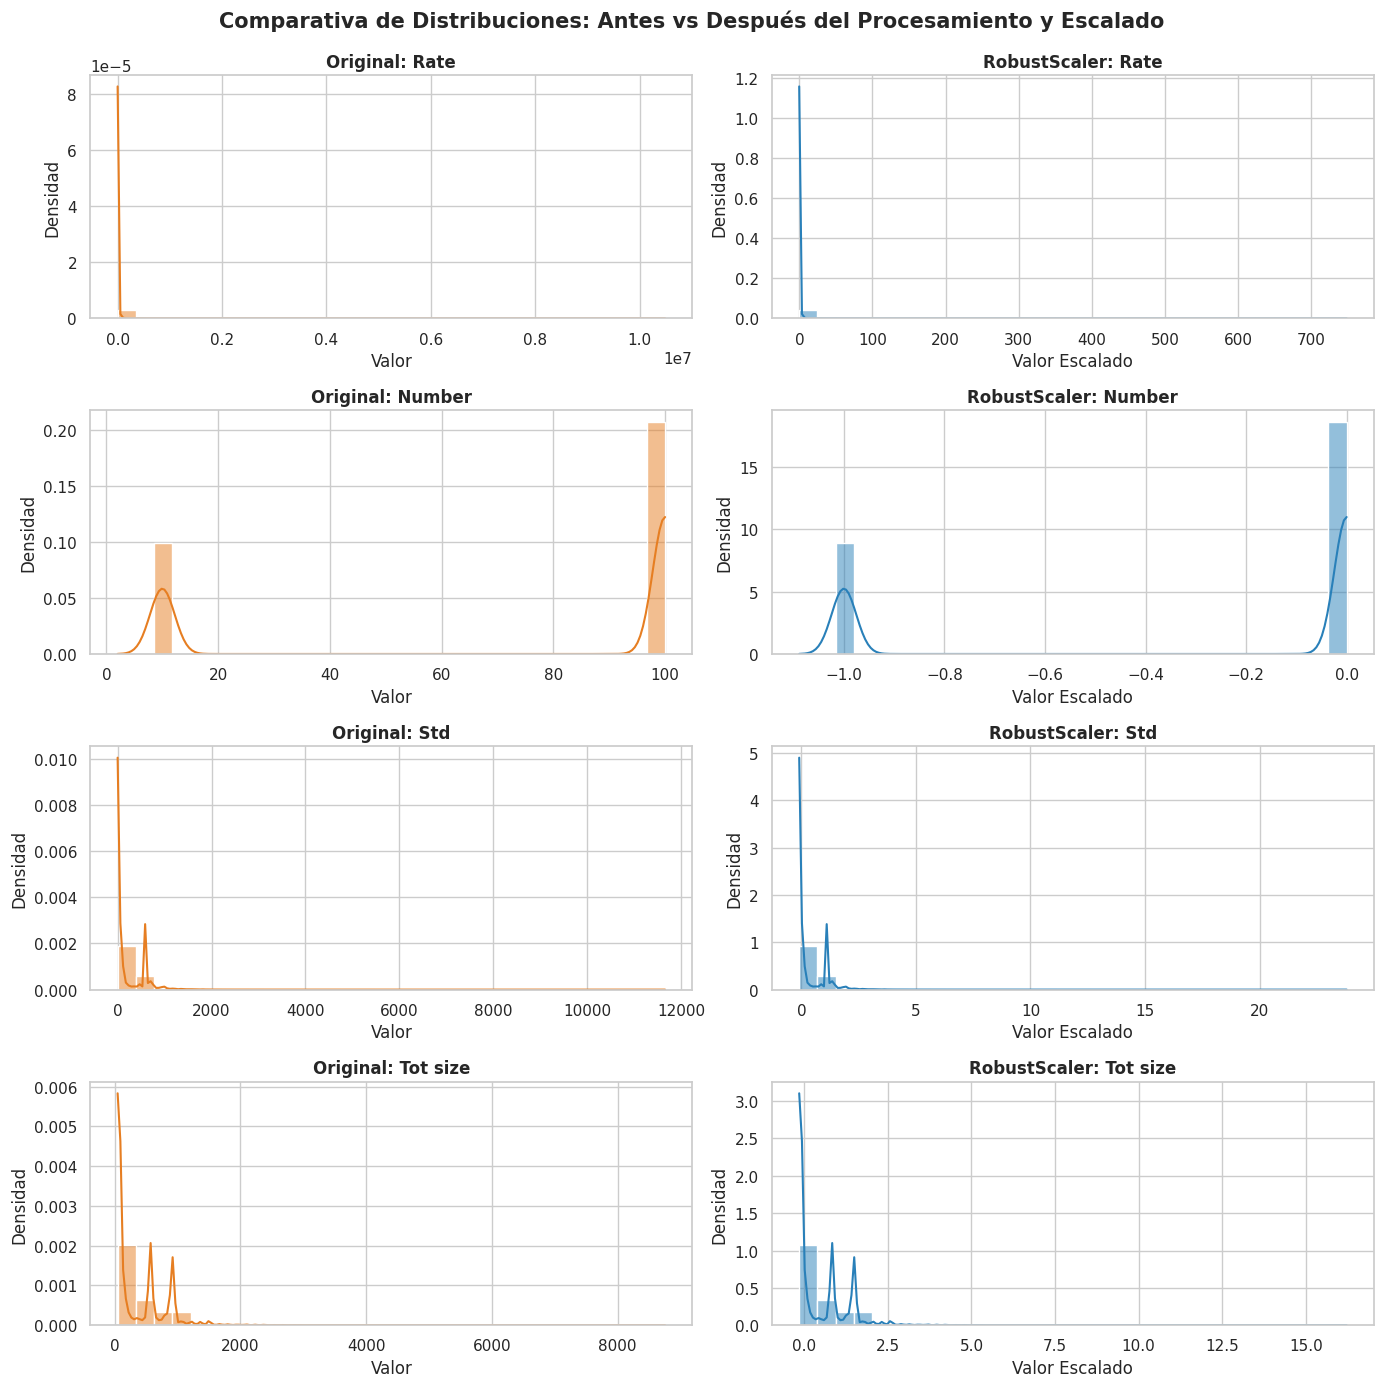

In [9]:
# Características de interés para comparar
cols_a_comparar = ['Rate', 'Number', 'Std', 'Tot size']
cols_a_comparar = [c for c in cols_a_comparar if c in df_before_scale.columns]

fig, axes = plt.subplots(len(cols_a_comparar), 2, figsize=(14, 3.5 * len(cols_a_comparar)))

for i, col in enumerate(cols_a_comparar):
    # Distribución antes de escalar (Verificación de escala original)
    sns.histplot(df_before_scale[col], bins=30, ax=axes[i, 0], color="#E67E22", kde=True, stat="density")
    axes[i, 0].set_title(f"Original: {col}", fontsize=12, fontweight='bold')
    axes[i, 0].set_xlabel("Valor")
    axes[i, 0].set_ylabel("Densidad")
    
    # Distribución después de escalar con RobustScaler
    sns.histplot(df_final[col], bins=30, ax=axes[i, 1], color="#2980B9", kde=True, stat="density")
    axes[i, 1].set_title(f"RobustScaler: {col}", fontsize=12, fontweight='bold')
    axes[i, 1].set_xlabel("Valor Escalado")
    axes[i, 1].set_ylabel("Densidad")

plt.suptitle("Comparativa de Distribuciones: Antes vs Después del Procesamiento y Escalado", 
             fontsize=15, fontweight='bold', y=0.99)
plt.tight_layout()
plt.savefig("results/figures/05_comparacion_limpieza.png", dpi=300)
plt.show()

## 8. Distribución de Clases en el Dataset Limpio

In [ ]:
class_counts = df_final['Label'].value_counts()
dist_final = pd.DataFrame({
    'Cantidad': class_counts,
    'Porcentaje': (class_counts / len(df_final) * 100).round(4)
})
print("Distribución final de clases tras la limpieza:")
print(dist_final)

# Guardar tabla de distribución para documentación de tesis
dist_final.to_csv("results/distribucion_clases_limpio.csv")